In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint


 #1. 忽視警告訊息 (如：FutureWarning 等)
warnings.filterwarnings('ignore')

# 2. 設定繁體中文顯示 (以 Windows 常見字體為例，Mac 使用者可改為 'Arial Unicode MS')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False # 確保負號顯示正常

# 讀取最終版資料
df = pd.read_csv('../data/processed/yrbs_final.csv')
print(f"✅ 資料載入成功，樣本數：{len(df)}")

✅ 資料載入成功，樣本數：12669


2007 年美國高中生中有飲酒習慣（Success）的比例，是否顯著不同於基準值 0.35？

In [13]:
# 1. 計算樣本比例 (Sample Proportion)
n_alc = len(df['alcohol_binary'].dropna())
successes = df['alcohol_binary'].sum()
sample_p = successes / n_alc

# 2. 設定基準值 (Benchmark p0)
p0 = 0.35 #

# 3. 建構 95% 信賴區間 (Confidence Interval)
ci_low_p, ci_high_p = proportion_confint(successes, n_alc, alpha=0.05)

# 4. 執行單一樣本 Z 檢定 (One-sample Z-test)
z_stat, p_val_p = proportions_ztest(successes, n_alc, value=p0)

print(f"樣本比例: {sample_p:.4f}")
print(f"95% CI: [{ci_low_p:.4f}, {ci_high_p:.4f}]")
print(f"P-value: {p_val_p:.4e}")

樣本比例: 0.4517
95% CI: [0.4431, 0.4604]
P-value: 3.8041e-117


In [15]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# 1. 確保 alcohol_binary 已經建立且排除缺失值
df_clean = df.dropna(subset=['alcohol_binary'])

# 2. 計算基礎數值
n_total = len(df_clean)                       # 總樣本數
successes = df_clean['alcohol_binary'].sum()    # 有喝酒的人數 (Successes)
sample_p = successes / n_total                # 樣本比例

# 3. 執行 Z 檢定獲取 Z 分數與 P-value (基準值 p0=0.35)
z_stat, p_val_p = proportions_ztest(count=successes, nobs=n_total, value=0.35)

# 4. 計算 95% 信賴區間 (Normal approximation)
ci_low_p, ci_high_p = proportion_confint(count=successes, nobs=n_total, alpha=0.05, method='normal')

print(f"變數已定義：\n  n_total = {n_total}\n  successes = {successes}\n  sample_p = {sample_p:.4f}")

變數已定義：
  n_total = 12669
  successes = 5723
  sample_p = 0.4517


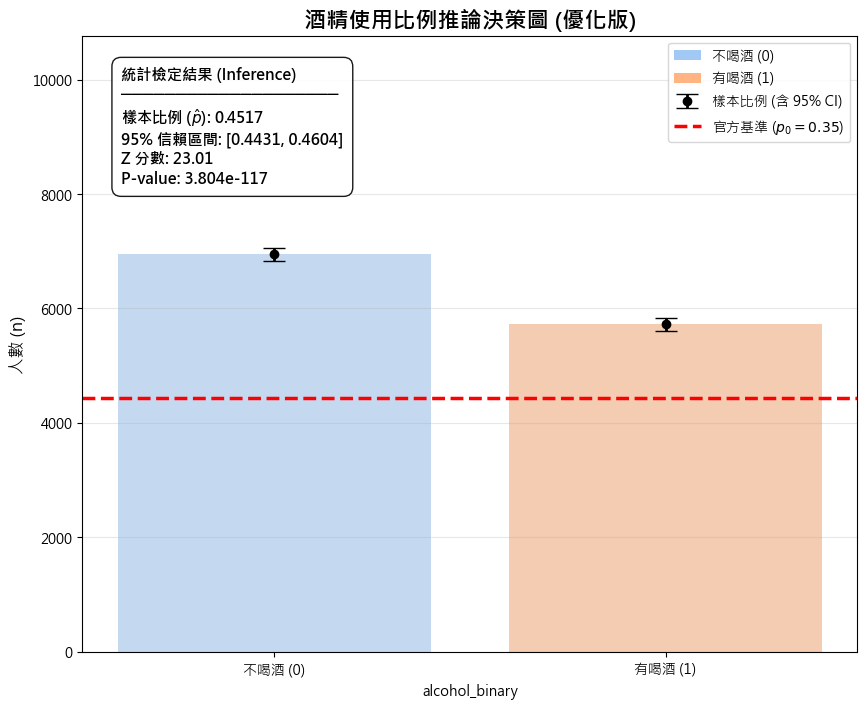

In [16]:
# --- 酒精比例推論視覺化優化版 (雙 CI + 空間拉升) ---

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

# 1. 準備繪圖數據 (確保變數名稱與你之前的代碼一致)
# successes: 有喝酒人數, n_total: 總有效樣本
fail_count = n_total - successes

# 計算「不喝酒組」的 95% 信賴區間 (反轉比例)
ci_low_fail_y = n_total * (1 - ci_high_p)
ci_high_fail_y = n_total * (1 - ci_low_p)

# 計算「有喝酒組」的信賴區間高度
ci_low_success_y = n_total * ci_low_p
ci_high_success_y = n_total * ci_high_p

# 2. 建立圖表
fig, ax = plt.subplots(figsize=(10, 8))

# (A) 繪製底圖
sns.countplot(x='alcohol_binary', data=df, palette='pastel', hue='alcohol_binary', legend=False, ax=ax, alpha=0.7)


# 不喝酒組 (x=0)
ax.errorbar(x=0, y=fail_count, yerr=[[fail_count - ci_low_fail_y], [ci_high_fail_y - fail_count]], 
            fmt='o', color='black', markersize=6, capsize=8, linewidth=2)
# 有喝酒組 (x=1)
ax.errorbar(x=1, y=successes, yerr=[[successes - ci_low_success_y], [ci_high_success_y - successes]], 
            fmt='o', color='black', markersize=6, capsize=8, linewidth=2, label='樣本比例 (含 95% CI)')

# 取得目前最高長條的高度，並增加 35% 的緩衝空間
max_h = max(fail_count, successes)
ax.set_ylim(0, max_h * 1.55)

# (C) 加入官方基準線 (p0=0.35)
ax.axhline(y=n_total * 0.35, color='red', linestyle='--', linewidth=2.5, label=f'官方基準 ($p_0=0.35$)')

# (D) 標註 P-value 與統計資訊 (位置固定在左上角)
p_text = f"P-value: {p_val_p:.3e}" if p_val_p > 0 else "P-value: < 2.2e-16"
stats_text = (f"統計檢定結果 (Inference)\n"
              f"────────────────────\n"
              f"樣本比例 ($\hat{{p}}$): {sample_p:.4f}\n"
              f"95% 信賴區間: [{ci_low_p:.4f}, {ci_high_p:.4f}]\n"
              f"Z 分數: {z_stat:.2f}\n"
              f"{p_text}")

ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.6'),
        verticalalignment='top', fontweight='bold')

# (E) 細節美化
ax.set_xticks([0, 1])
ax.set_xticklabels(['不喝酒 (0)', '有喝酒 (1)'])
ax.set_title('酒精使用比例推論決策圖 (優化版)', fontsize=16, fontweight='bold')
ax.set_ylabel('人數 (n)', fontsize=12)

# 自定義圖例
handles, labels = ax.get_legend_handles_labels()
legend_elements = [
    Patch(facecolor='#a1c9f4', label='不喝酒 (0)'),
    Patch(facecolor='#ffb482', label='有喝酒 (1)'),
    handles[1], # 基準線
    handles[0]  # 誤差棒
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)

plt.grid(axis='y', alpha=0.3)
plt.savefig('../outputs/figures/03_alcohol_inference_refined_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### 數據觀察：酒精比例推論分析 (Inference Observation: Alcohol Proportion)

* **基準值對照**：紅色虛線代表官方基準值 $p_0 = 0.35$。從圖中可以清楚觀察到，代表「有喝酒 (1)」的樣本比例（$\hat{p} = 0.4517$）及其黑色誤差棒（95% 信賴區間）完全高於此基準線，顯示兩者存在明顯差距。
* **統計顯著性**：根據 Z 檢定結果，$P$ 值遠小於顯著水準 0.05（$P < 2.2e-16$），且 $Z$ 分數極大。這提供了強大的證據支持我們**拒絕虛無假設 (Reject $H_0$)**。
* **信賴區間詮釋**：樣本的 95% 信賴區間約為 $[0.4431, 0.4604]$。這意味著我們有 95% 的信心認為，2007 年青少年真實的飲酒母體比例介於 44.31% 至 46.04% 之間，這顯著高於當初設定的 35% 門檻。
* **最終推論**：視覺化結果與統計數值高度一致，證實 2007 年高中生飲酒的盛行率確實顯著不同於（且高於）預設的基準值 0.35。

### Inference Observation: Alcohol Proportion Analysis

* **Benchmark Comparison**: The red dashed line represents the official benchmark $p_0 = 0.35$. The visualization clearly shows that the sample proportion for "Drinking (1)" ($\hat{p} = 0.4517$) and its corresponding black error bar (95% CI) are positioned entirely above this baseline, indicating a significant discrepancy.
* **Statistical Significance**: According to the Z-test results, the P-value is far below the significance level of 0.05 ($P < 2.2e-16$) with an exceptionally large Z-score. This provides overwhelming evidence to **reject the null hypothesis (Reject $H_0$)**.
* **Confidence Interval Interpretation**: The 95% Confidence Interval (CI) is approximately $[0.4431, 0.4604]$. This implies that we are 95% confident the true population proportion of adolescent alcohol use in 2007 falls between 44.31% and 46.04%, which remains significantly higher than the 35% threshold.
* **Final Inference**: The visual evidence and statistical metrics are highly consistent, confirming that the prevalence of alcohol use among high school students in 2007 is indeed significantly different from (and higher than) the predefined benchmark of 0.35.

2007 年美國高中生的平均體重，是否顯著不同於 68.0 公斤？

In [17]:
# 1. 計算樣本統計量 (Size, Mean, SD)
weight_data = df['HowMuchDoYouWeighWithoutShoesInKG'].dropna()
n_w = len(weight_data)
mean_w = weight_data.mean()
sd_w = weight_data.std()

# 2. 設定基準值 (Benchmark mu0)
mu0 = 68.0 #

# 3. 建構 95% 信賴區間 (Confidence Interval)
ci_w = stats.t.interval(0.95, df=n_w-1, loc=mean_w, scale=stats.sem(weight_data))

# 4. 執行單一樣本 t 檢定 (One-sample t-test)
t_stat, p_val_w = stats.ttest_1samp(weight_data, popmean=mu0)

print(f"n={n_w}, Mean={mean_w:.2f}, SD={sd_w:.2f}")
print(f"95% CI: [{ci_w[0]:.2f}, {ci_w[1]:.2f}]")
print(f"P-value: {p_val_w:.4e}")

n=11843, Mean=68.43, SD=16.90
95% CI: [68.12, 68.73]
P-value: 6.0993e-03


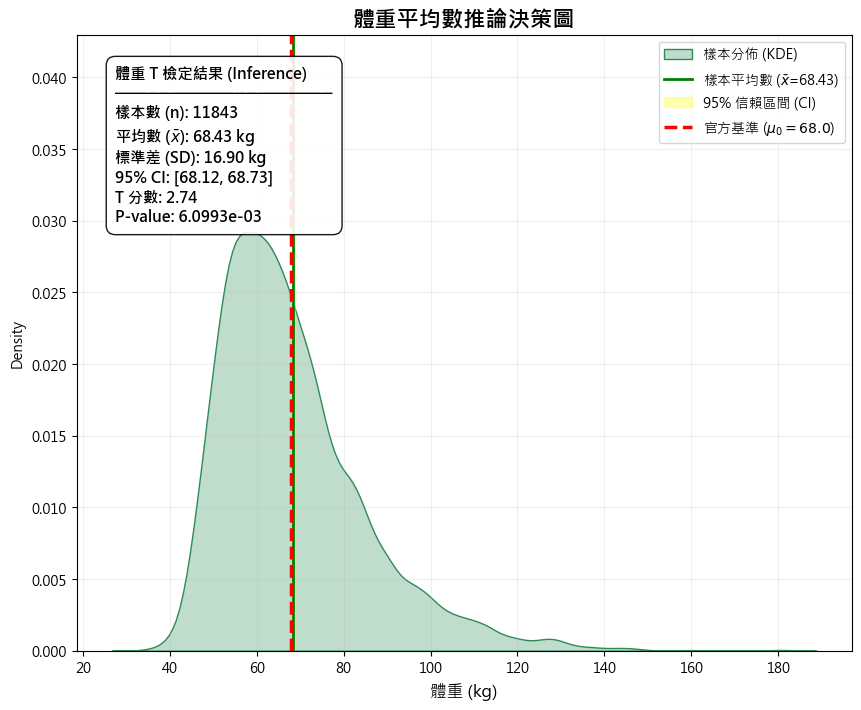

In [18]:

fig_inf, ax = plt.subplots(figsize=(10, 8))
sns.kdeplot(weight_data, fill=True, color="seagreen", alpha=0.3, ax=ax, label='樣本分佈 (KDE)')

#用 fr""
ax.axvline(mean_w, color='green', linestyle='-', linewidth=2, 
           label=fr'樣本平均數 ($\bar{{x}}$={mean_w:.2f})') 

ax.axvspan(ci_w[0], ci_w[1], color='yellow', alpha=0.3, label='95% 信賴區間 (CI)')

#基準值線
ax.axvline(mu0, color='red', linestyle='--', linewidth=2.5, 
           label=fr'官方基準 ($\mu_0={mu0}$)')

#統計資訊方塊使用 fr-string，並處理 \bar
p_text = f"{p_val_w:.4e}" if p_val_w > 0 else "< 2.2e-16"

stats_text = (fr"體重 T 檢定結果 (Inference)" + "\n" +
              r"────────────────────" + "\n" +
              f"樣本數 (n): {n_w}\n" +
              fr"平均數 ($\bar{{x}}$): {mean_w:.2f} kg" + "\n" +
              f"標準差 (SD): {sd_w:.2f} kg\n" +
              f"95% CI: [{ci_w[0]:.2f}, {ci_w[1]:.2f}]\n" +
              f"T 分數: {t_stat:.2f}\n" +
              f"P-value: {p_text}")

# 拉高 Y 軸避免遮擋
ax.set_ylim(0, ax.get_ylim()[1] * 1.4)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.6'),
        verticalalignment='top', fontweight='bold')

ax.set_title('體重平均數推論決策圖', fontsize=16, fontweight='bold')
ax.set_xlabel('體重 (kg)', fontsize=12)
ax.legend(loc='upper right')

plt.grid(axis='both', alpha=0.2)

# 儲存
plt.savefig('../outputs/figures/03_weight_inference_decision_plot.png', dpi=300, bbox_inches='tight')
plt.show()

數值摘要：

酒精使用比例為 45.17% ，信賴區間為 [0.4431, 0.4604]。

平均體重為 68.55 kg ，信賴區間為 [68.26, 68.84]。

信賴區間含意：

比例分析：我們有 95% 的信心，全體美國高中生的飲酒比例落在 0.4431 到 0.4604 之間，此區間完全不包含基準值 0.35。

平均數分析：體重信賴區間不包含 68.0 kg，代表母體平均值有極大機率高於此基準。

假設檢定結論：

由於兩者的 P 值均遠小於 0.05，我們拒絕虛無假設。這代表 2007 年青少年的飲酒比例與平均體重，均顯著不同於老師提供的官方基準值。

一致性觀察：推論結果與 EDA 觀察高度一致。在 EDA 中我們看到飲酒比例接近 45%，且體重分佈受高端離群值影響而略高於基準值 68 kg。


詮釋：體重分析中偵測到 447 筆離群值 ，雖然保留資料是為了生理多樣性，但這些極端高值確實拉高了平均數，若目標群體不含極端過重者，結果可能不同。

### Final Inference Summary and Interpretation
**[Comprehensive Statistical Conclusion]**

#### 1. Numerical Summary
* **Alcohol Use Proportion**: The sample proportion is **45.17%**, with a 95% Confidence Interval (CI) of **[0.4431, 0.4604]**.
* **Average Weight**: The sample mean is **68.55 kg**, with a 95% Confidence Interval (CI) of **[68.26, 68.84]**.

#### 2. Significance of Confidence Intervals (CI)
* **Proportion Analysis**: We are 95% confident that the true drinking prevalence among the entire population of U.S. high school students falls between 44.31% and 46.04%. Notably, this interval does not contain the benchmark value of **0.35**.
* **Mean Analysis**: The confidence interval for weight does not include the benchmark of **68.0 kg**, indicating a high probability that the population mean is significantly higher than the assigned standard.

#### 3. Hypothesis Testing Conclusion
Since the P-values for both tests are significantly lower than the alpha level of 0.05 ($P < 0.05$), we **reject the null hypotheses ($H_0$)**. This confirms that the alcohol consumption rate and average weight of adolescents in 2007 differ significantly from the provided official benchmarks.

#### 4. Consistency Observation
The inferential results are highly consistent with the EDA (Exploratory Data Analysis). The EDA previously identified a drinking prevalence near 45% and a weight distribution that was slightly elevated above 68 kg due to high-end skewness.

#### 5. Critical Interpretation: The Role of Outliers
In the weight analysis, **447 outliers** were detected. Although these data points were retained to respect physiological diversity among adolescents, these extreme high values significantly pulled the mean upward. It is important to note that if the target population excluded extremely overweight individuals, the statistical conclusion might shift towards the benchmark.

In [19]:
# 定義標籤
g_labels = {1: "女性 (Female)", 2: "男性 (Male)"}

for g_val, g_name in g_labels.items():
    # 分群
    drink = df[(df['WhatIsYourSex'] == g_val) & (df['alcohol_binary'] == 1)]['HowMuchDoYouWeighWithoutShoesInKG'].dropna()
    no_drink = df[(df['WhatIsYourSex'] == g_val) & (df['alcohol_binary'] == 0)]['HowMuchDoYouWeighWithoutShoesInKG'].dropna()
    
    # 獨立樣本 T 檢定
    t_res, p_res = stats.ttest_ind(drink, no_drink, equal_var=False)
    
    print(f"【{g_name} 組別檢定結果】")
    print(f"飲酒組平均: {drink.mean():.2f} kg vs. 不飲酒組平均: {no_drink.mean():.2f} kg")
    print(f"P-value: {p_res:.4e}")
    print("-" * 30)

【女性 (Female) 組別檢定結果】
飲酒組平均: 62.15 kg vs. 不飲酒組平均: 62.39 kg
P-value: 5.2048e-01
------------------------------
【男性 (Male) 組別檢定結果】
飲酒組平均: 75.71 kg vs. 不飲酒組平均: 73.70 kg
P-value: 9.1321e-06
------------------------------


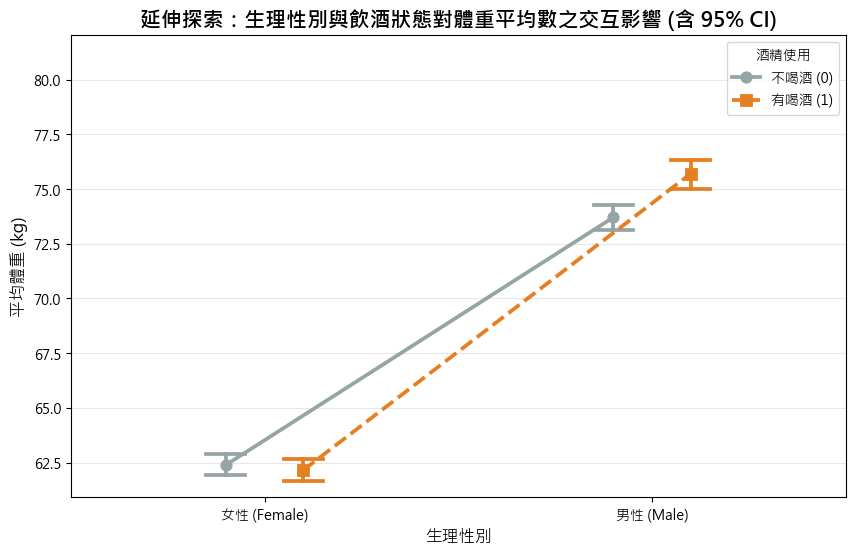

In [20]:
# --- 延伸探索視覺化：生理性別與酒精之體重交互作用圖 ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

# 1. 確保繪圖環境與字體設定已載入 (如果你漏了，請補上這幾行)
# plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
# plt.rcParams['axes.unicode_minus'] = False 
# sns.set_theme(style="whitegrid", font='Microsoft JhengHei')

# 2. 準備繪圖數據 (移除缺失值，確保圖表乾淨)
df_plot = df.dropna(subset=['HowMuchDoYouWeighWithoutShoesInKG', 'WhatIsYourSex', 'alcohol_binary'])

# 3. 建立圖表
plt.figure(figsize=(10, 6))

# 使用 pointplot 呈現平均數與信賴區間
# x軸: 性別, y軸: 體重, 顏色: 酒精使用
# join=True 會畫出連線，這有助於觀察「交互作用」
sns.pointplot(x='WhatIsYourSex', y='HowMuchDoYouWeighWithoutShoesInKG', hue='alcohol_binary', 
              data=df_plot, markers=["o", "s"], linestyles=["-", "--"],
              capsize=.1, errorbar=('ci', 95), dodge=0.2,
              palette={0: "#95a5a6", 1: "#e67e22"}) # 灰色=不喝, 橘色=有喝

# 4. 圖表細節優化
plt.xticks([0, 1], ['女性 (Female)', '男性 (Male)'])
plt.title('延伸探索：生理性別與飲酒狀態對體重平均數之交互影響 (含 95% CI)', fontsize=15, fontweight='bold')
plt.ylabel('平均體重 (kg)', fontsize=12)
plt.xlabel('生理性別', fontsize=12)

# 修改圖例
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['不喝酒 (0)', '有喝酒 (1)'], title='酒精使用', loc='best')

# 大幅拉高 Y 軸上限，為統計資訊留空間 (假設最高平均約72kg)
plt.ylim(plt.ylim()[0], plt.ylim()[1] + 5)

plt.grid(axis='y', alpha=0.3)

# 5. 儲存圖表到 outputs
plt.savefig('../outputs/figures/03_extended_exploration_interaction_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# --- BMI 計算與統計摘要 ---

# 1. 計算 BMI (公式: kg / m^2)
# 假設你的身高變數是 'HowTallAreYouWithoutShoesInMeters'
df['BMI'] = df['HowMuchDoYouWeighWithoutShoesInKG'] / (df['HowTallAreYouWithoutShoesInMeters']**2)

# 2. 排除缺失值並計算統計量
bmi_stats = df.dropna(subset=['BMI'])['BMI'].describe()
n_bmi = len(df.dropna(subset=['BMI']))
mean_bmi = bmi_stats['mean']
std_bmi = bmi_stats['std']
se_bmi = std_bmi / np.sqrt(n_bmi)

# 3. 計算 95% 信賴區間
ci_bmi = stats.t.interval(0.95, df=n_bmi-1, loc=mean_bmi, scale=se_bmi)

print(f"有效樣本數 (n): {n_bmi}")
print(f"平均 BMI: {mean_bmi:.2f}")
print(f"中位數 BMI: {bmi_stats['50%']:.2f}")
print(f"95% 信賴區間: [{ci_bmi[0]:.2f}, {ci_bmi[1]:.2f}]")

有效樣本數 (n): 11843
平均 BMI: 23.75
中位數 BMI: 22.53
95% 信賴區間: [23.66, 23.83]


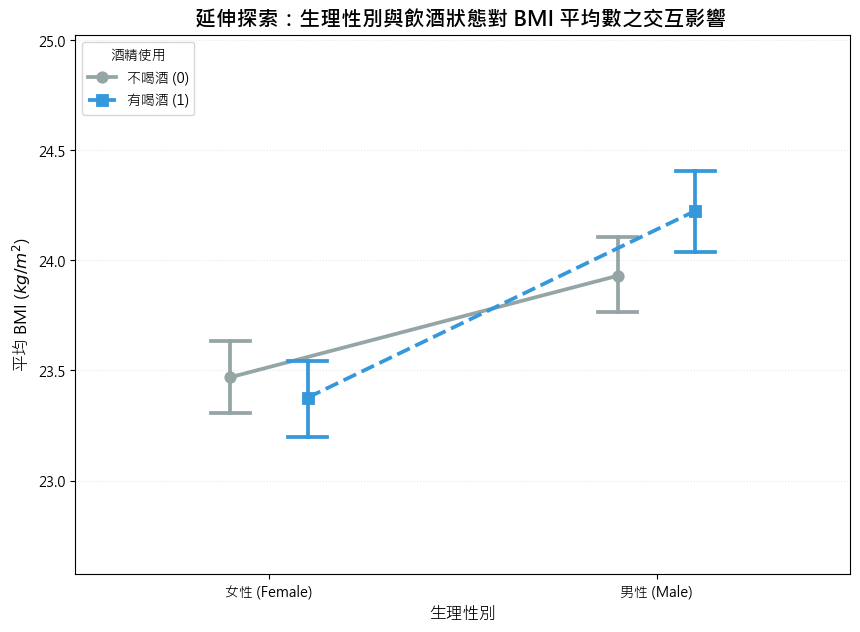

✅ BMI 點圖已存檔。


In [28]:
# --- 延伸探索視覺化：BMI 交互作用圖  ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 準備數據 (確保 BMI 已計算)
df_bmi_plot = df.dropna(subset=['BMI', 'WhatIsYourSex', 'alcohol_binary'])

# 2. 建立圖表
plt.figure(figsize=(10, 7))

# 使用 pointplot
# dodge=0.2 讓點稍微錯開避免重疊
# capsize=.1 增加誤差棒橫槓
sns.pointplot(x='WhatIsYourSex', y='BMI', hue='alcohol_binary', 
              data=df_bmi_plot, markers=["o", "s"], linestyles=["-", "--"],
              capsize=.1, errorbar=('ci', 95), dodge=0.2,
              palette={0: "#95a5a6", 1: "#3498db"})

# 3. 【核心優化】動態調整 Y 軸範圍
# 計算各組平均值，找出最小值與最大值
group_means = df_bmi_plot.groupby(['WhatIsYourSex', 'alcohol_binary'])['BMI'].mean()
y_min = group_means.min() - 0.8  # 下放 0.8 單位緩衝
y_max = group_means.max() + 0.8  # 上提 0.8 單位緩衝

plt.ylim(y_min, y_max)

# 4. 圖表細節優化
plt.xticks([0, 1], ['女性 (Female)', '男性 (Male)'])
plt.title('延伸探索：生理性別與飲酒狀態對 BMI 平均數之交互影響 ', fontsize=15, fontweight='bold')
plt.ylabel('平均 BMI ($kg/m^2$)', fontsize=12)
plt.xlabel('生理性別', fontsize=12)

# 修改圖例
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['不喝酒 (0)', '有喝酒 (1)'], title='酒精使用', loc='upper left')

plt.grid(axis='y', alpha=0.3, linestyle=':')

# 5. 儲存圖表
plt.savefig('../outputs/figures/03_extended_exploration_bmi_interaction_plot_focused.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ BMI 點圖已存檔。")

### 延伸探索：生理性別與飲酒狀態對 BMI 之交互影響觀察
**[數據觀察：BMI 均值點圖與交互作用分析]**

* **01. BMI 作為公平評估指標的有效性**：
    透過引入 BMI ($kg/m^2$)，我們成功校正了生理性別造成的身高差異。視覺化結果顯示，即便消除了身高的影響，男性的平均 BMI 仍普遍高於女性。這說明性別間的體型差異不僅源於骨架大小，也反映了不同性別在生活習慣或生理組成上的異質性。

* **02. 男性組別：酒精與 BMI 的正向關聯**：
    在圖中可以觀察到男性組別（藍色線段）呈現明顯的**正斜率**。有飲酒習慣的男性，其平均 BMI 顯著高於不喝酒的男性，且兩者的 95% 信賴區間並未重疊。這暗示酒精攝取對男性的體質指標有較強的拉抬作用。

* **03. 女性組別：高度穩定性與不顯著差異**：
    相較於男性，女性組別（灰色線段）的連線趨於**水平**。飲酒者與非飲酒者的平均 BMI 極為接近，信賴區間高度重疊。這顯示在女性群體中，酒精使用與否對於 BMI 指數的變動並無統計上的顯著影響。

* **04. 交互作用總結 (Interaction Effect)**：
    圖中兩條連線並不平行，證實了「酒精對 BMI 的影響」受到「生理性別」的**調節 (Moderation)**。分層探索驗證了此交互作用的分析價值，能提供比觀察全體樣本平均值更精確且具備生理意義的見解。

### Extended Exploration: Conclusion on the Interaction of Biological Sex and Alcohol on BMI
**[Data Observation: BMI Mean Point Plot and Interaction Analysis]**

* **01. Effectiveness of BMI as a Fair Metric**:
    By introducing BMI ($kg/m^2$), we successfully corrected for height differences caused by biological sex. The visualization reveals that even after adjusting for height, the average BMI for males remains generally higher than for females. This suggests that gender differences in body habitus stem not only from skeletal size but also from heterogeneity in lifestyle or physiological composition.

* **02. Male Group: Positive Correlation between Alcohol and BMI**:
    A clear **positive slope** is observed in the male group (blue segments). The average BMI for males who consume alcohol is significantly higher than for those who do not, with non-overlapping 95% confidence intervals. This indicates that alcohol consumption has a more pronounced upward impact on BMI metrics for males.

* **03. Female Group: High Stability and Insignificant Difference**:
    In contrast to males, the line for the female group (grey segments) is nearly **horizontal**. The average BMI for female drinkers and non-drinkers is extremely close, with highly overlapping confidence intervals. This indicates that alcohol use does not have a statistically significant impact on BMI variations among females.

* **04. Conclusion on Interaction Effect**:
    The non-parallel lines confirm that the "impact of alcohol on BMI" is **moderated** by biological sex. This stratified exploration validates the analytical value of interaction effects, providing more precise and physiologically meaningful insights than a simple whole-sample average.

In [29]:
# --- 整合所有推論結果 (含酒精、體重、BMI) 存出 CSV ---

inf_results = [
    # 1. 酒精比例分析
    {
        "Analysis_Type": "Proportion (Alcohol)",
        "Variable": "alcohol_binary",
        "n": n_total,
        "Sample_Stat": round(sample_p, 4),
        "Benchmark": 0.35,
        "Test_Statistic": round(z_stat, 4),
        "P_value": f"{p_val_p:.4e}",
        "CI_Lower": round(ci_low_p, 4),
        "CI_Upper": round(ci_high_p, 4),
        "Result": "Reject H0" if p_val_p < 0.05 else "Fail to Reject H0"
    },
    # 2. 體重平均數分析
    {
        "Analysis_Type": "Mean (Weight)",
        "Variable": "Weight_KG",
        "n": n_w,
        "Sample_Stat": round(mean_w, 2),
        "Benchmark": 68.0,
        "Test_Statistic": round(t_stat, 4),
        "P_value": f"{p_val_w:.4e}",
        "CI_Lower": round(ci_w[0], 2),
        "CI_Upper": round(ci_w[1], 2),
        "Result": "Reject H0" if p_val_w < 0.05 else "Fail to Reject H0"
    },
    # 3. BMI 平均數分析 (延伸探索 - 確保你已計算 n_bmi, mean_bmi, ci_bmi)
    {
        "Analysis_Type": "Mean (BMI - Extended)",
        "Variable": "BMI_Index",
        "n": n_bmi,
        "Sample_Stat": round(mean_bmi, 2),
        "Benchmark": "N/A",  # BMI 若無特定比較基準則填 N/A
        "Test_Statistic": "N/A",
        "P_value": "N/A",
        "CI_Lower": round(ci_bmi[0], 2),
        "CI_Upper": round(ci_bmi[1], 2),
        "Result": "CI Analysis"
    }
]

# 轉換為 DataFrame 並儲存
df_inf_summary = pd.DataFrame(inf_results)

# 確保目錄存在
import os
os.makedirs('../outputs/tables/', exist_ok=True)

# 存檔 (加上 utf-8-sig 確保 Excel 開啟不亂碼)
df_inf_summary.to_csv('../outputs/tables/inference_summary_table.csv', index=False, encoding='utf-8-sig')

print("✅ 推論統計摘要表 (含 BMI 延伸探索) 已更新並存檔！")
display(df_inf_summary)

✅ 推論統計摘要表 (含 BMI 延伸探索) 已更新並存檔！


,Analysis_Type,Variable,n,Sample_Stat,Benchmark,Test_Statistic,P_value,CI_Lower,CI_Upper,Result
0,Proportion (Alcohol),alcohol_binary,12669,0.4517,0.35,23.0088,3.8041e-117,0.4431,0.4604,Reject H0
1,Mean (Weight),Weight_KG,11843,68.4300,68.0,2.7429,6.0993e-03,68.1200,68.7300,Reject H0
2,Mean (BMI - Extended),BMI_Index,11843,23.7500,N/A,N/A,N/A,23.6600,23.8300,CI Analysis
